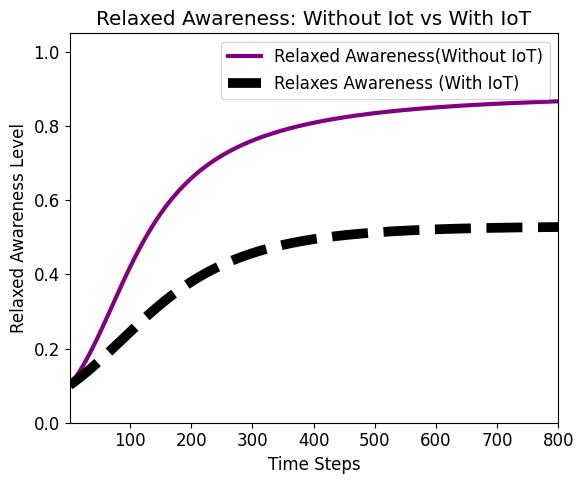

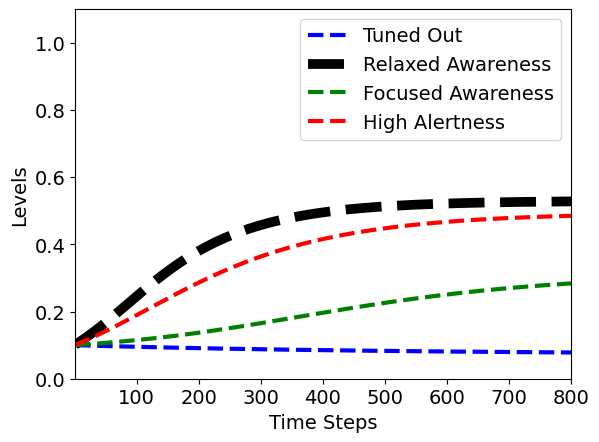

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters (kept original values)
# -----------------------
njc = 0.7
bct = 0.7
yal = 0.7
nal = 0.7
uat = 0.7
acm = 0.7
bim = 0.7
nim = 0.7
yjd = 0.7
ysp = 0.7
aar = 0.7
war = 0.50

Snra = 0.7
Sara = 0.33
Swfa = 0.33
Snfa = 0.7
Sato = 0.7
Sbra = 0.7
Syar = 0.7
Sbar = 0.7

LnRa = 0.3
LnFa = 0.3
LnHa = 0.3
LnTo = 0.3

#for Ct equation
muCt = 0.8
sigmaCt = 0.5
muLCt = 0.7

#for At equation
muAt = 0.7
sigmaAt = 0.4
muLAt = 0.4

#for Ar equation
muAr = 0.9
sigmaAr = 0.5
muLAr = 0.3

# Sensor priority weights
wF_At, wS_At, wG_At = 0.80, 0.50, 0.10
wF_Ct, wS_Ct, wG_Ct = 0.90, 0.40, 0.20
wF_Ar, wS_Ar, wG_Ar = 0.70, 0.50, 0.20

delT = 0.1
numTime = 800


# ===============================
# Initialize arrays
# ===============================


Ex = np.zeros(numTime)
Pr = np.zeros(numTime)
Re = np.zeros(numTime)
Ir = np.zeros(numTime)
Ip = np.zeros(numTime)
Tp = np.zeros(numTime)
Jd = np.zeros(numTime)
Cu = np.zeros(numTime)
Ls = np.zeros(numTime)

Jc = np.zeros(numTime)
Ct = np.zeros(numTime)
Al = np.zeros(numTime)
At = np.zeros(numTime)
Ar = np.zeros(numTime)
Cm = np.zeros(numTime)
Im = np.zeros(numTime)
Rt = np.zeros(numTime)
Sp = np.zeros(numTime)
SRa = np.zeros(numTime)
SFa = np.zeros(numTime)
SHa = np.zeros(numTime)
STo = np.zeros(numTime)
LRa = np.zeros(numTime)
LFa = np.zeros(numTime)
LHa = np.zeros(numTime)
LTo = np.zeros(numTime)


SAt = np.zeros(numTime)
SCt = np.zeros(numTime)
SAr = np.zeros(numTime)

LAt = np.zeros(numTime)
LCt = np.zeros(numTime)
LAr = np.zeros(numTime)

SAt_newIoT = np.zeros(numTime)
SCt_newIoT = np.zeros(numTime)
SAr_newIoT = np.zeros(numTime)

LAt_newIoT = np.zeros(numTime)
LCt_newIoT = np.zeros(numTime)
LAr_newIoT = np.zeros(numTime)

SRa_newIoT = np.zeros(numTime)
SFa_newIoT = np.zeros(numTime)
SHa_newIoT = np.zeros(numTime)
STo_newIoT = np.zeros(numTime)

LRa_newIoT = np.zeros(numTime)
LFa_newIoT = np.zeros(numTime)
LTo_newIoT = np.zeros(numTime)
LHa_newIoT = np.zeros(numTime)
# Sensor Arrays
FIR = np.zeros(numTime)
GAS = np.zeros(numTime)
SMO = np.zeros(numTime)



# Initial conditions
#original
LRa[0] = 0.1
LFa[0] = 0.1
LTo[0] = 0.1
LHa[0] = 0.1

#new initials conditions
LAt[0] = 0.1
LCt[0] = 0.1
LAr[0] = 0.1

SAt[0] = 0.1
SCt[0] = 0.1
SAr[0] = 0.1
SHa[0] = 0.1

#with iot initials conditions
LAt_newIoT[0] = 0.1
LCt_newIoT[0] = 0.1
LAr_newIoT[0] = 0.1

SRa_newIoT[0] = 0.1
SFa_newIoT[0] = 0.1
SHa_newIoT[0] = 0.1
STo_newIoT[0] = 0.1


LRa_newIoT[0] = 0.1
LFa_newIoT[0] = 0.1
LTo_newIoT[0] = 0.1
LHa_newIoT[0] = 0.1


# Initial values for some arrays
for t in range(numTime):
    Ex[t] = 0.9
    Pr[t] = 0.9
    Re[t] = 0.9
    Ir[t] = 0.9
    Ip[t] = 0.9
    Tp[t] = 0.1
    Cu[t] = 0.9
    Ls[t] = 0.9
    Rt[t] = 0.1

    #iot sensors

    FIR[t] = 0.8
    SMO[t] = 0.5
    GAS[t] = 0.3



start_i = 0

# Run Model WITHOUT IoT

# Initial calculations
Jc[start_i] = njc * Pr[start_i] + (1 - njc) * Ex[start_i]
Cm[start_i] = acm * Ls[start_i] + (1 - acm) * Cu[start_i]
Jd[start_i] = Tp[start_i] * (1 - Jc[start_i])
Ct[start_i] = Rt[start_i] * (1 - Re[start_i])
Im[start_i] = nim * Ls[start_i] + (1 - nim) * Re[start_i]
At[start_i] = (uat * Ir[start_i] + (1 - uat) * Ip[start_i]) * (1 - Pr[start_i])
Al[start_i] = (1 - nal) * At[start_i] + nal * LHa[start_i]
Sp[start_i] = ysp * Jc[start_i] + (1 - ysp) * Ex[start_i]
Ar[start_i] = (aar * Tp[start_i] + (1 - aar) * Jd[start_i]) * (1 - (war * Cm[start_i] + war * Im[start_i]))
SRa[start_i] = (Sara * Sp[start_i] + Sara * Cm[start_i] + Sara * Im[start_i]) * (1 - Ct[start_i])
SHa[start_i] = Sbar * (Ar[start_i] + (1 - Syar) * At[start_i]) + (1 - Sbar) * LHa[start_i]
SFa[start_i] = Snfa * (Swfa * At[start_i] + Swfa * Rt[start_i] + Swfa * LFa[start_i]) + (1 - Snfa) * LHa[start_i]
STo[start_i] = Sato * (Rt[start_i] * (1 - At[start_i])) + (1 - Sato) * LTo[start_i]

#main loop without iot

for t in range(1, numTime):
    Jc[t] = njc * Pr[t] + (1 - njc) * Ex[t]
    Cm[t] = acm * Ls[t] + (1 - acm) * Cu[t]
    Jd[t] = Tp[t] * (1 - Jc[t])
    Ct[t] = Rt[t] * (1 - Re[t])
    Im[t] = nim * Ls[t] + (1 - nim) * Re[t]
    At[t] = (uat * Ir[t] + (1 - uat) * Ip[t]) * (1 - Pr[t])
    Al[t] = (1 - nal) * At[t] + nal * LHa[t-1]
    Sp[t] = ysp * Jc[t] + (1 - ysp) * Ex[t]
    Ar[t] = (aar * Tp[t] + (1 - aar) * Jd[t]) * (1 - (war * Cm[t] + war * Im[t]))
    SRa[t] = (Sara * Sp[t] + Sara * Cm[t] + Sara * Im[t]) * (1 - Ct[t])
    SHa[t] = Sbar * (Ar[t] + (1 - Syar) * At[t]) + (1 - Sbar) * LHa[t-1]
    SFa[t] = Snfa * (Swfa * At[t] + Swfa * Rt[t] + Swfa * LFa[t-1]) + (1 - Snfa) * LHa[t-1]
    STo[t] = Sato * (Rt[t] * (1 - At[t])) + (1 - Sato) * LTo[t-1]
    LRa[t] = LRa[t-1] + LnRa * (SRa[t-1] - LRa[t-1]) * (1 - LRa[t-1]) * LRa[t-1] * delT
    LFa[t] = LFa[t-1] + LnFa * (SFa[t-1] - LFa[t-1]) * (1 - LFa[t-1]) * LFa[t-1] * delT
    LHa[t] = LHa[t-1] + LnHa * (SHa[t-1] - LHa[t-1]) * (1 - LHa[t-1]) * LHa[t-1] * delT
    LTo[t] = LTo[t-1] + LnTo * (STo[t-1] - LTo[t-1]) * (1 - LTo[t-1]) * LTo[t-1] * delT


#with IoT

# Initial calculations
Jc[start_i] = njc * Pr[start_i] + (1 - njc) * Ex[start_i]
Cm[start_i] = acm * Ls[start_i] + (1 - acm) * Cu[start_i]
Jd[start_i] = Tp[start_i] * (1 - Jc[start_i])
Ct[start_i] = Rt[start_i] * (1 - Re[start_i])
Im[start_i] = nim * Ls[start_i] + (1 - nim) * Re[start_i]
At[start_i] = (uat * Ir[start_i] + (1 - uat) * Ip[start_i]) * (1 - Pr[start_i])
Al[start_i] = (1 - nal) * At[start_i] + nal * LHa[start_i]
Sp[start_i] = ysp * Jc[start_i] + (1 - ysp) * Ex[start_i]
Ar[start_i] = (aar * Tp[start_i] + (1 - aar) * Jd[start_i]) * (1 - (war * Cm[start_i] + war * Im[start_i]))
SRa[start_i] = (Sara * Sp[start_i] + Sara * Cm[start_i] + Sara * Im[start_i]) * (1 - Ct[start_i])
SHa[start_i] = Sbar * (Ar[start_i] + (1 - Syar) * At[start_i]) + (1 - Sbar) * LHa[start_i]
SFa[start_i] = Snfa * (Swfa * At[start_i] + Swfa * Rt[start_i] + Swfa * LFa[start_i]) + (1 - Snfa) * LHa[start_i]
STo[start_i] = Sato * (Rt[start_i] * (1 - At[start_i])) + (1 - Sato) * LTo[start_i]

# ---- IoT aggregator values first (start_i) ----
N = 3.0  # normalisation (number of sensors)
IoT_At = wF_At * FIR[start_i] + wS_At * SMO[start_i] + wG_At * GAS[start_i]
IoT_Ct = wF_Ct * FIR[start_i] + wS_Ct * SMO[start_i] + wG_Ct * GAS[start_i]
IoT_Ar = wF_Ar * FIR[start_i] + wS_Ar * SMO[start_i] + wG_Ar * GAS[start_i]

# ---- IoT-driven short-term proposals at start_i ----
SAt_newIoT[start_i] = muAt * (sigmaAt * IoT_At + (1 - sigmaAt) * (LFa[start_i] / N)) + (1 - muAt) * At[start_i]
SCt_newIoT[start_i] = muCt * (sigmaCt * IoT_Ct + (1 - sigmaCt) * (LFa[start_i] / N)) + (1 - muCt) * Ct[start_i]
SAr_newIoT[start_i] = muAr * (sigmaAr * IoT_Ar + (1 - sigmaAr) * (LFa[start_i] / N)) + (1 - muAr) * Ar[start_i]

# ---- IoT auxiliary short-term signals at start_i (use IoT S-terms) ----
SRa_newIoT[start_i] = (Sara * Sp[start_i] + Sara * Cm[start_i] + Sara * Im[start_i]) * (1 - SCt_newIoT[start_i])
SHa_newIoT[start_i] = Sbar * (SAr_newIoT[start_i] + (1 - Syar) * SAt_newIoT[start_i]) + (1 - Sbar) * LHa_newIoT[start_i]
SFa_newIoT[start_i] = Snfa * (Swfa * SAt_newIoT[start_i] + Swfa * Rt[start_i] + Swfa * LFa_newIoT[start_i]) + (1 - Snfa) * LHa_newIoT[start_i]
STo_newIoT[start_i] = Sato * (Rt[start_i] * (1 - SAt_newIoT[start_i])) + (1 - Sato) * LTo_newIoT[start_i]

# ---- Long-term IoT updates at start_i ----
# Attention: use muLAt and compare SAt_newIoT vs At
LAt_newIoT[start_i] = LAt_newIoT[start_i] + muLAt * (SAt_newIoT[start_i] - At[start_i]) * delT

# Challenge: use muLCt and compare SCt_newIoT vs Ct
LCt_newIoT[start_i] = LCt_newIoT[start_i] + muLCt * (SCt_newIoT[start_i] - Ct[start_i]) * delT

# Adrenaline: smooth toward SAr using previous LAr_newIoT value
LAr_newIoT[start_i] = LAr_newIoT[start_i] + muLAr * (SAr_newIoT[start_i] - LAr_newIoT[start_i]) * delT

# Auxiliary long-term IoT states: logistic-like update
LRa_newIoT[start_i] = LRa_newIoT[start_i] + LnRa * (SRa_newIoT[start_i] - LRa_newIoT[start_i]) * (1 - LRa_newIoT[start_i]) * LRa_newIoT[start_i] * delT
LFa_newIoT[start_i] = LFa_newIoT[start_i] + LnFa * (SFa_newIoT[start_i] - LFa_newIoT[start_i]) * (1 - LFa_newIoT[start_i]) * LFa_newIoT[start_i] * delT
LHa_newIoT[start_i] = LHa_newIoT[start_i] + LnHa * (SHa_newIoT[start_i] - LHa_newIoT[start_i]) * (1 - LHa_newIoT[start_i]) * LHa_newIoT[start_i] * delT
LTo_newIoT[start_i] = LTo_newIoT[start_i] + LnTo * (STo_newIoT[start_i] - LTo_newIoT[start_i]) * (1 - LTo_newIoT[start_i]) * LTo_newIoT[start_i] * delT

#main loop with iot

for t in range(1, numTime):
    Jc[t] = njc * Pr[t] + (1 - njc) * Ex[t]
    Cm[t] = acm * Ls[t] + (1 - acm) * Cu[t]
    Jd[t] = Tp[t] * (1 - Jc[t])
    Ct[t] = Rt[t] * (1 - Re[t])
    Im[t] = nim * Ls[t] + (1 - nim) * Re[t]
    At[t] = (uat * Ir[t] + (1 - uat) * Ip[t]) * (1 - Pr[t])
    Al[t] = (1 - nal) * At[t] + nal * LHa[t-1]
    Sp[t] = ysp * Jc[t] + (1 - ysp) * Ex[t]
    Ar[t] = (aar * Tp[t] + (1 - aar) * Jd[t]) * (1 - (war * Cm[t] + war * Im[t]))
    SRa[t] = (Sara * Sp[t] + Sara * Cm[t] + Sara * Im[t]) * (1 - Ct[t])
    SHa[t] = Sbar * (Ar[t] + (1 - Syar) * At[t]) + (1 - Sbar) * LHa[t-1]
    SFa[t] = Snfa * (Swfa * At[t] + Swfa * Rt[t] + Swfa * LFa[t-1]) + (1 - Snfa) * LHa[t-1]
    STo[t] = Sato * (Rt[t] * (1 - At[t])) + (1 - Sato) * LTo[t-1]
    LRa[t] = LRa[t-1] + LnRa * (SRa[t-1] - LRa[t-1]) * (1 - LRa[t-1]) * LRa[t-1] * delT
    LFa[t] = LFa[t-1] + LnFa * (SFa[t-1] - LFa[t-1]) * (1 - LFa[t-1]) * LFa[t-1] * delT
    LHa[t] = LHa[t-1] + LnHa * (SHa[t-1] - LHa[t-1]) * (1 - LHa[t-1]) * LHa[t-1] * delT
    LTo[t] = LTo[t-1] + LnTo * (STo[t-1] - LTo[t-1]) * (1 - LTo[t-1]) * LTo[t-1] * delT

    IoT_At = wF_At * FIR[t] + wS_At * SMO[t] + wG_At * GAS[t]
    IoT_Ct = wF_Ct * FIR[t] + wS_Ct * SMO[t] + wG_Ct * GAS[t]
    IoT_Ar = wF_Ar * FIR[t] + wS_Ar * SMO[t] + wG_Ar * GAS[t]

    N = 3.0  # number of sensors
    SAt_newIoT[t] = muAt * (sigmaAt * IoT_At + (1 - sigmaAt) * (LFa[t-1] / N)) + (1 - muAt) * At[t]
    SCt_newIoT[t] = muCt * (sigmaCt * IoT_Ct + (1 - sigmaCt) * (LFa[t-1] / N)) + (1 - muCt) * Ct[t]
    SAr_newIoT[t] = muAr * (sigmaAr * IoT_Ar + (1 - sigmaAr) * (LFa[t-1] / N)) + (1 - muAr) * Ar[t]

    LAt_newIoT[t] = LAt_newIoT[t-1] + muLAt * (SAt_newIoT[t] - At[t]) * delT
    LCt_newIoT[t] = LCt_newIoT[t-1] + muLCt * (SCt_newIoT[t] - Ct[t]) * delT
    LAr_newIoT[t] = LAr_newIoT[t-1] + muLAr * (SAr_newIoT[t] - LAr_newIoT[t-1]) * delT

    SRa_newIoT[t] = (Sara * Sp[t] + Sara * Cm[t] + Sara * Im[t]) * (1 - SCt_newIoT[t])
    SHa_newIoT[t] = Sbar * (SAr_newIoT[t] + (1 - Syar) * SAt_newIoT[t]) + (1 - Sbar) * LHa_newIoT[t-1]
    SFa_newIoT[t] = Snfa * (Swfa * SAt_newIoT[t] + Swfa * Rt[t] + Swfa * LFa_newIoT[t-1]) + (1 - Snfa) * LHa_newIoT[t-1]
    STo_newIoT[t] = Sato * (Rt[t] * (1 - SAt_newIoT[t])) + (1 - Sato) * LTo_newIoT[t-1]

    LRa_newIoT[t] = LRa_newIoT[t-1] + LnRa * (SRa_newIoT[t-1] - LRa_newIoT[t-1]) * (1 - LRa_newIoT[t-1]) * LRa_newIoT[t-1] * delT
    LFa_newIoT[t] = LFa_newIoT[t-1] + LnFa * (SFa_newIoT[t-1] - LFa_newIoT[t-1]) * (1 - LFa_newIoT[t-1]) * LFa_newIoT[t-1] * delT
    LHa_newIoT[t] = LHa_newIoT[t-1] + LnHa * (SHa_newIoT[t-1] - LHa_newIoT[t-1]) * (1 - LHa_newIoT[t-1]) * LHa_newIoT[t-1] * delT
    LTo_newIoT[t] = LTo_newIoT[t-1] + LnTo * (STo_newIoT[t-1] - LTo_newIoT[t-1]) * (1 - LTo_newIoT[t-1]) * LTo_newIoT[t-1] * delT

time = np.arange(1, numTime + 1)

plot_x = np.arange(1, numTime + 1)

plt.figure(figsize=(6, 5))
plt.rcParams.update({'font.size': 12})

plt.plot(plot_x, LRa, '-', linewidth=3,color='purple', label='Relaxed Awareness(Without IoT)')

plt.plot(plot_x, LRa_newIoT, '--', linewidth=7, color='black',label= 'Relaxes Awareness (With IoT)')

plt.xlabel('Time Steps')
plt.ylabel('Relaxed Awareness Level')
plt.title('Relaxed Awareness: Without Iot vs With IoT')
plt.xlim([1, numTime])
plt.ylim([0, 1.05])
plt.legend()
plt.tight_layout()
plt.show()


# Plotting
plt.figure()
plt.rcParams.update({'font.size': 14})
t = np.arange(1, numTime + 1)
y1, = plt.plot(t, LTo_newIoT, 'b--', linewidth=3, label='Tuned Out')
y2, = plt.plot(t, LRa_newIoT, 'k--', linewidth=7, label='Relaxed Awareness')
y3, = plt.plot(t, LFa_newIoT, 'g--', linewidth=3, label='Focused Awareness')
y4, = plt.plot(t, LHa_newIoT, 'r--', linewidth=3, label='High Alertness')
plt.xlabel('Time Steps')
plt.ylabel('Levels')
plt.xlim([1, 800])
plt.ylim([0, 1.1])
plt.legend()
plt.show()